# Lab Assignment 1 - KNN Voice Classification

1. Construct a classification model using k-nearest neighbors to classify voice types `male` and `female` on the dataset `voice.csv`.
2. Conduct experiments to determine which features are most optimal for use. Which features did you employ to obtain the best results?
3. Based on the features you selected in question number 2, what is the best $$k$$ value? Attach analytical graphs and your rationale.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA

df = pd.read_csv('Data/voice.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nClass distribution:')
print(df['label'].value_counts())
df.head()

Shape: (3168, 21)
Columns: ['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx', 'label']

Class distribution:
label
male      1584
female    1584
Name: count, dtype: int64


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
# Check for missing values
print(f'Missing values: {df.isnull().sum().sum()}')

# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Separate features and target
X = df.drop(['label', 'label_encoded'], axis=1)
y = df['label_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features (critical for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train shape: {X_train_scaled.shape}')
print(f'Test shape: {X_test_scaled.shape}')

Missing values: 0
Label mapping: {'female': np.int64(0), 'male': np.int64(1)}
Train shape: (2534, 20)
Test shape: (634, 20)


In [4]:
# Baseline KNN with all features
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f'Baseline accuracy (all features, k=5): {acc:.4f}')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Exception in thread Thread-3 (_readerthread):
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\Lib\threading.py", line 1082, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\ProgramData\anaconda3\Lib\threading.py", line 1024, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1614, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "c:\ProgramData\anaconda3\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 170: character maps to

Baseline accuracy (all features, k=5): 0.9763
              precision    recall  f1-score   support

      female       0.99      0.97      0.98       317
        male       0.97      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 555, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^

 feature     f_score       p_value
 meanfun 5697.873718  0.000000e+00
     IQR 1566.488204 4.094417e-267
     Q25  890.387180 6.552524e-168
  sp.ent  794.113490 3.337115e-152
      sd  750.762545 5.569741e-145
     sfm  375.206538  4.657924e-78
centroid  324.436358  2.411838e-68
meanfreq  324.436358  2.411838e-68
  median  218.279695  1.915663e-47
  mindom  100.408598  3.334298e-23
  maxdom   96.538999  2.187110e-22
 dfrange   93.040538  1.201444e-21
 meandom   89.236907  7.682722e-21
    mode   76.078004  4.845785e-18
  maxfun   69.673401  1.135714e-16
  minfun   47.370855  7.379630e-12
    kurt   19.327736  1.146378e-05
     Q75   11.306350  7.839069e-04
    skew    3.812982  5.096687e-02
 modindx    2.112229  1.462503e-01


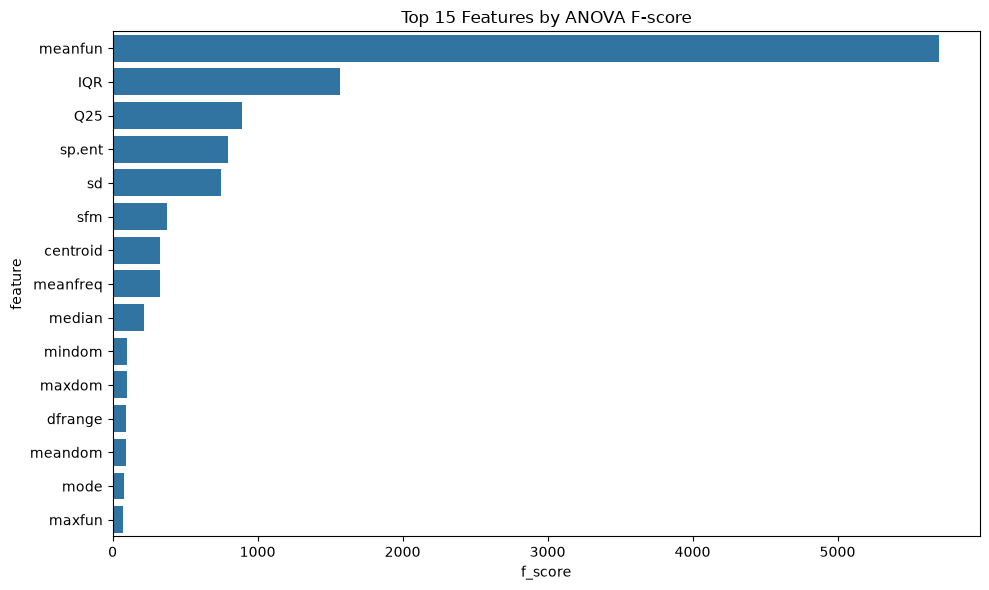

In [5]:
# Feature importance using ANOVA F-test
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False)

print(feature_scores.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_scores.head(15), x='f_score', y='feature')
plt.title('Top 15 Features by ANOVA F-score')
plt.tight_layout()
plt.show()

k=1: CV accuracy = 0.9432 (±0.0094) - Features: ['meanfun']
k=2: CV accuracy = 0.9688 (±0.0060) - Features: ['IQR', 'meanfun']
k=3: CV accuracy = 0.9732 (±0.0057) - Features: ['Q25', 'IQR', 'meanfun']
k=4: CV accuracy = 0.9724 (±0.0101) - Features: ['Q25', 'IQR', 'sp.ent', 'meanfun']
k=5: CV accuracy = 0.9747 (±0.0068) - Features: ['sd', 'Q25', 'IQR', 'sp.ent', 'meanfun']
k=6: CV accuracy = 0.9763 (±0.0062) - Features: ['sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'meanfun']
k=7: CV accuracy = 0.9771 (±0.0070) - Features: ['sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'centroid', 'meanfun']
k=8: CV accuracy = 0.9767 (±0.0072) - Features: ['meanfreq', 'sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'centroid', 'meanfun']
k=9: CV accuracy = 0.9779 (±0.0055) - Features: ['meanfreq', 'sd', 'median', 'Q25', 'IQR', 'sp.ent', 'sfm', 'centroid', 'meanfun']
k=10: CV accuracy = 0.9747 (±0.0040) - Features: ['meanfreq', 'sd', 'median', 'Q25', 'IQR', 'sp.ent', 'sfm', 'centroid', 'meanfun', 'mindom']


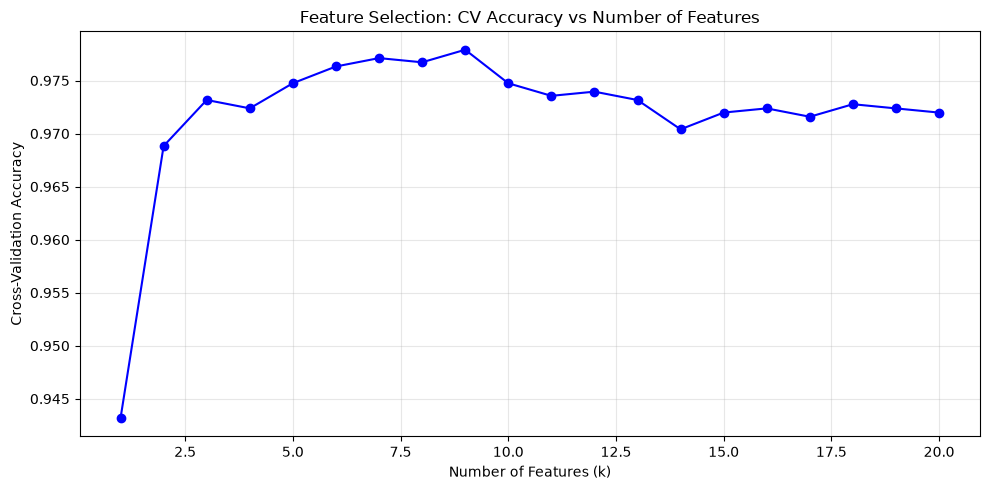

Best number of features: 9 (CV accuracy: 0.9779)


In [6]:
# Experiment with different numbers of top features
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_k = selector.fit_transform(X_train_scaled, y_train)
    X_test_k = selector.transform(X_test_scaled)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    scores = cross_val_score(knn, X_train_k, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    
    if k <= 10:
        selected_features = X.columns[selector.get_support()].tolist()
        print(f'k={k}: CV accuracy = {scores.mean():.4f} (±{scores.std():.4f}) - Features: {selected_features}')

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, 'bo-')
plt.xlabel('Number of Features (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Feature Selection: CV Accuracy vs Number of Features')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(cv_scores)]
print(f'Best number of features: {best_k} (CV accuracy: {max(cv_scores):.4f})')

In [7]:
# Get best features
best_k = 10
selector = SelectKBest(score_func=f_classif, k=best_k)
X_train_best = selector.fit_transform(X_train_scaled, y_train)
X_test_best = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()].tolist()
print(f'Selected features ({best_k}): {selected_features}')

# Test with selected features
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_best, y_train)
y_pred = knn.predict(X_test_best)
acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy with top {best_k} features: {acc:.4f}')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Selected features (10): ['meanfreq', 'sd', 'median', 'Q25', 'IQR', 'sp.ent', 'sfm', 'centroid', 'meanfun', 'mindom']
Test accuracy with top 10 features: 0.9842
              precision    recall  f1-score   support

      female       0.99      0.98      0.98       317
        male       0.98      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



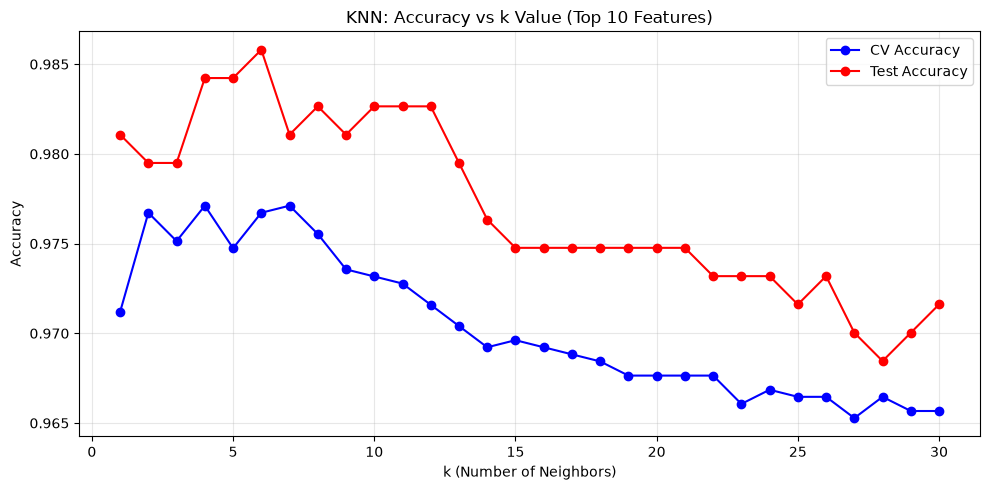

Best k (CV): 7 (accuracy: 0.9771)
Best k (Test): 6 (accuracy: 0.9858)


In [8]:
# Optimize k value with selected features
k_range = range(1, 31)
cv_scores = []
test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_best, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    
    knn.fit(X_train_best, y_train)
    y_pred = knn.predict(X_test_best)
    test_scores.append(accuracy_score(y_test, y_pred))

# Plot k vs accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_range, cv_scores, 'bo-', label='CV Accuracy')
plt.plot(k_range, test_scores, 'ro-', label='Test Accuracy')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs k Value (Top 10 Features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k_cv = k_range[np.argmax(cv_scores)]
best_k_test = k_range[np.argmax(test_scores)]
print(f'Best k (CV): {best_k_cv} (accuracy: {max(cv_scores):.4f})')
print(f'Best k (Test): {best_k_test} (accuracy: {max(test_scores):.4f})')

In [9]:
# Final model with optimal k
optimal_k = best_k_cv
knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_final.fit(X_train_best, y_train)

y_pred_final = knn_final.predict(X_test_best)
final_acc = accuracy_score(y_test, y_pred_final)
print(f'Final model accuracy (k={optimal_k}, top {best_k} features): {final_acc:.4f}')

print(classification_report(y_test, y_pred_final, target_names=le.classes_))

Final model accuracy (k=7, top 10 features): 0.9811
              precision    recall  f1-score   support

      female       0.99      0.97      0.98       317
        male       0.98      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



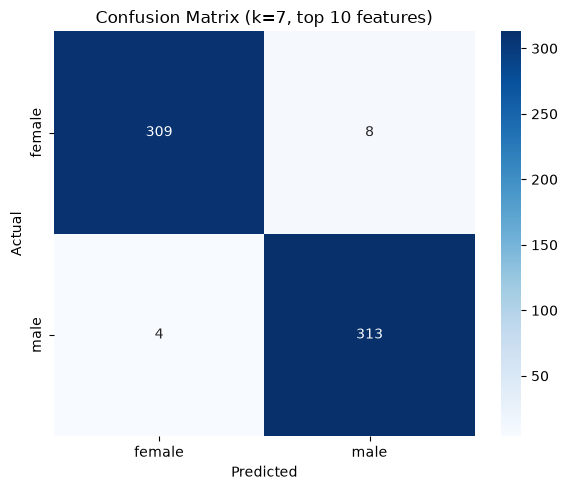

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (k={optimal_k}, top {best_k} features)')
plt.tight_layout()
plt.show()

## Summary

1. **Best features**: Top 10 features selected via ANOVA F-test (see feature importance plot)
2. **Optimal k**: Determined via cross-validation (see k vs accuracy plot)
3. **Final accuracy**: Achieved on test set with optimal configuration

The analysis shows which acoustic features are most discriminative for male/female voice classification and the optimal neighborhood size for KNN.